# CSE2530 Computational Intelligence
## Assignment 2: Artificial Neural Networks

<div style="background-color:#f1be3e">

_Fill in your group number **from Brightspace**, names, and student numbers._
    
|    Group   |           61          |
|------------|----------------------|
| Student A  |        XXXXXXX       |
| Student B  |        XXXXXXX       |
| Student C  |        XXXXXXX       |
| Student D  |        XXXXXXX       |

</div>

#### Imports

In [30]:
# You may only use numpy to implement your neural network
# You are not allowed to use scikit-learn, other than for Section 1.6.
# You are also not allowed to use Pytorch, Tensorflow, and similar machine learning frameworks.
# You can make use of any other libraries for miscellaneous functions, e.g. to create the visual aids.

# Put all of your imports in this code block
import numpy as np
import matplotlib.pyplot as plt
import copy

#### Seed

In [ ]:
# We use fixed seed to ensure reproducibility of our results
# NOTE: im not sure if this is what they mean "to ensure reproducibility"
# np.random.seed(10)

#### Loading the data

In [31]:
features = np.genfromtxt("../data/features.txt", delimiter=",") # 7854 samples of 10 features
targets = np.genfromtxt("../data/targets.txt", delimiter=",")   # 7854 target classes of the samples mentioned above
unknown = np.genfromtxt("../data/unknown.txt", delimiter=",")   # 784 samples of 10 features, with no lables available

## 1 Questions
### 1.2 Architecture
#### Question 1:

In [32]:
def sigmoid(z):
    return 1 / (1 + np.exp(-z))

def derivative_sigmoid(z):
    return sigmoid(z) * (1- sigmoid(z))

def forward_propagation(x, w, b):
    z = np.dot(x, w) + b
    h = sigmoid(z)
    return z, h

def loss_function(h, true_y):
    return np.sum((true_y-h)**2)

def backward_propagation(x, true_y, h, z, w, b, a):
    m = x.shape[0]
    
    dL_dh = -2 * (true_y - h)
    dh_dz = derivative_sigmoid(z)
    dL_dz = dL_dh * dh_dz

    dL_dw = np.dot(x.T, dL_dz) / m
    dL_db = np.sum(dL_dz) / m

    updated_w = w - (a * dL_dw)
    updated_b = b - (a * dL_db)

    return updated_w, updated_b


def training(x, true_y):
    l = []
    x = np.array(x, dtype=float)
    true_y = np.array(true_y, dtype=float).reshape(-1, 1)

    w = np.zeros((x.shape[1], 1)) 
    b = 0.0
    a = 0.5
    for epoch in range(1000):
        z, h = forward_propagation(x, w, b)
        loss = loss_function(h, true_y)
        l.append(loss)
        if (epoch % 100 == 0):
            print("Epoch ", epoch , ": " , loss)
        w, b = backward_propagation(x, true_y, h, z, w, b, a)
    return l

# AND
x = [[0, 0], [0, 1], [1, 0], [1, 1]]
true_y = [0, 0, 0, 1]
training(x, true_y)

# OR
x = [[0, 0], [0, 1], [1, 0], [1, 1]]
true_y = [0, 1, 1, 1]
training(x, true_y)

# XOR
x = [[0, 0], [0, 1], [1, 0], [1, 1]]
true_y = [1, 0, 0, 1]
training(x, true_y)



Epoch  0 :  1.0
Epoch  100 :  0.3772583836468483
Epoch  200 :  0.23694953192230744
Epoch  300 :  0.1694810596346552
Epoch  400 :  0.12983248546308385
Epoch  500 :  0.1040811631921289
Epoch  600 :  0.08621744609086206
Epoch  700 :  0.07321101252048338
Epoch  800 :  0.06337999340714667
Epoch  900 :  0.05572392271873505
Epoch  0 :  1.0
Epoch  100 :  0.26807432390970015
Epoch  200 :  0.15100720758802957
Epoch  300 :  0.09998620885085698
Epoch  400 :  0.07298213267688444
Epoch  500 :  0.05673346458795382
Epoch  600 :  0.04605116317367578
Epoch  700 :  0.038565421828921864
Epoch  800 :  0.033062902256611605
Epoch  900 :  0.028865974520720945
Epoch  0 :  1.0
Epoch  100 :  1.0
Epoch  200 :  1.0
Epoch  300 :  1.0
Epoch  400 :  1.0
Epoch  500 :  1.0
Epoch  600 :  1.0
Epoch  700 :  1.0
Epoch  800 :  1.0
Epoch  900 :  1.0


[np.float64(1.0),
 np.float64(1.0),
 np.float64(1.0),
 np.float64(1.0),
 np.float64(1.0),
 np.float64(1.0),
 np.float64(1.0),
 np.float64(1.0),
 np.float64(1.0),
 np.float64(1.0),
 np.float64(1.0),
 np.float64(1.0),
 np.float64(1.0),
 np.float64(1.0),
 np.float64(1.0),
 np.float64(1.0),
 np.float64(1.0),
 np.float64(1.0),
 np.float64(1.0),
 np.float64(1.0),
 np.float64(1.0),
 np.float64(1.0),
 np.float64(1.0),
 np.float64(1.0),
 np.float64(1.0),
 np.float64(1.0),
 np.float64(1.0),
 np.float64(1.0),
 np.float64(1.0),
 np.float64(1.0),
 np.float64(1.0),
 np.float64(1.0),
 np.float64(1.0),
 np.float64(1.0),
 np.float64(1.0),
 np.float64(1.0),
 np.float64(1.0),
 np.float64(1.0),
 np.float64(1.0),
 np.float64(1.0),
 np.float64(1.0),
 np.float64(1.0),
 np.float64(1.0),
 np.float64(1.0),
 np.float64(1.0),
 np.float64(1.0),
 np.float64(1.0),
 np.float64(1.0),
 np.float64(1.0),
 np.float64(1.0),
 np.float64(1.0),
 np.float64(1.0),
 np.float64(1.0),
 np.float64(1.0),
 np.float64(1.0),
 np.float6

#TODO: Explain what we did in questions 1, give correct and informative plots and add sensible discussion of all plots

<h4>Question 2: How many input neurons are needed in our classification task as described above? </h4>


The number of input neurons is fixed by the number of features in the input data. Since we have 10 features, we need 10 input neurons.

<h4>Question 3: How many output neurons do you require?</h4>

The number of output neurons is fixed by the task type. Since the task is to classify objects into multiple separate classes, one ouput neuron per class is required. Since there are 7 classes, the network will have 7 output neurons.

<h4>Question 4: How many hidden neurons and layers will your network have?

The number of hidden neurons and layers is determined by balancing the dataset complexity, available computational power and the risk of overfitting. Our dataset consists of 10 meaningful, human-designed features per sample and is of moderate size. Given this, a network with 1 hidden layer is a reasonable starting point, as a second layer would only be needed if the patterns are more complex or hierarchical.

There is no strict formula for choosing the numnber of neurons in a hidden layers, but common heuristics provide guidance. Two widely used rules are "the between the input and output size" rule and the 2/3 rule. The first suggests a number between the input and output size, in our case that would mean: (input + output)/2 = (10 + 7)/2 ≈ 8 neurons. The 2/3 rule gives (2/3) * input + output = (2/3) * 10 + 7 ≈ 14. These values are usually enough to learn simple patterns, but may not capture more subtle feature interactions.

To provide extra capacity while maintaining computational efficiency, we decided to roughly double the heuristic values, giving 30 neurons. Following standard practice of using powers of 2, we rounded this to 32 neurons.

During experimentation, if the network underfits (fails to learn the patterns), the number of neurons can be increased, and if it overfits (memorises the training data), they can be reduced. A second hidden layer can be added if the network struggles to capture more complex or hierarchical relationships.

<h4>Question 5: Which activation function(s) will you use?</h4>

#TODO: discuss sigmoid and ..., give pros and cons per activation function

<h4>Question 6: Give a schematic diagram of your complete network based on your previous answers</h4>

#TODO

### 1.3 Training

When coding a neural network from scratch, it helps to think of a layer as an individual component that can be easily combined with other layers. To help you create a modular implementation of a neural network, we provide you with a template for the implementation along with some explanations.

**Note that using the template below is not mandatory. You may choose to modify this template or implement your own version of the neural network altogether. If the latter, please remove our template from the notebook and ensure that it instead includes a complete, fully functional implementation of your own.**

**Linear (fully connected) layer**

A linear or fully connected layer maps the input data to an output by performing a linear transformation, where each input neuron is connected to every output neuron. The forward pass of a linear layer is computed as $y = wx + b$, where $w$ and $b$ are trainable parameters. The gradients of the loss with respect to $w$ and $b$ are defined using the chain rule:

$$\frac{\partial \mathcal{L}}{\partial w}=\frac{\partial \mathcal{L}}{\partial y} \cdot \frac{\partial y}{\partial w}, \quad \frac{\partial \mathcal{L}}{\partial b}=\frac{\partial \mathcal{L}}{\partial y} \cdot \frac{\partial y}{\partial b}, $$

where $\frac{\partial \mathcal{L}}{\partial y}$ is the upstream gradient i.e., the gradient flowing from deeper layers into the current layer, and the other two terms are the local gradients:

$$
\frac{\partial y}{\partial w}=x, \quad \frac{\partial y}{\partial b}=1.
$$

Since $x$ is needed to compute the gradients, we can store (cache) its value during the forward pass. Finally, we need to return a downstream gradient so that more shallow layers can use it as their upstream gradient. The downstream gradient of a layer is simply its upstream gradient multiplied by the local gradient of its ouput with respect to its input:

$$
\frac{\partial \mathcal{L}}{\partial x}=\frac{\partial \mathcal{L}}{\partial y} \cdot \frac{\partial y}{\partial x}
$$

**Note.** Be aware of how you multiply the arrays, it might be useful to print the shapes of each array and to think about the desired shape of the output.  

In [60]:
# Despite the instruction above suggesting x to be just one input. We make our program so that it allows batches of x at a time to speed up. 
class Linear:
    def __init__(self, in_features, out_features, init_mode_weight=1, init_mode_bias=0):
        """ Randomly initialize the weights and biases.

        Args:
            in_features: number of input features.
            out_features: number of output features.
            init_mode_weight: mode of initialization for weights, we support:
              0 = all weights to zeroes (pointless but just to find out that then network does not work)
              1 = He initialization (common choice for ReLU)
              2 = Xavier initialization (rather preferred for sigmoid, but we'll try nevertheless)
              3 = Gaussian distribution
              4 = Uniform distribution: U(-0.05, 0.05)
            init_mode_bias: mode of bias initialization:
              0 = all zeroes (usual choice)
              1 = bias initialized accordingly to weight mode (U(-var, var)), 
                I don't think this is necessary but we are asked to randomly initialize the weights AND BIASES
        """
        self.bias = np.zeros((out_features))
        if init_mode_weight == 0:
            self.weight = np.zeros((out_features, in_features))
        elif init_mode_weight == 1:
            std = np.sqrt(2/in_features)
        elif init_mode_weight == 2:
            std = np.sqrt(1/in_features)
        elif init_mode_weight == 3:
            std = 1
        elif init_mode_weight == 4:
            self.weight = np.random.uniform(-0.05, 0.05, (out_features, in_features))
            if init_mode_bias == 1:
                self.bias = np.random.uniform(-0.05, 0.05, (out_features)) 

        if init_mode_weight != 0 and init_mode_weight != 4:
            self.weight = np.random.normal(0.0, std, (out_features, in_features))
            if init_mode_bias == 1:
                self.bias = np.random.uniform(-std, std, (out_features)) 
        

        self.cache = None
        # For storing the gradients w.r.t. the weight and the bias
        self.weight_grad = None
        self.bias_grad = None

    def forward(self, x):
        """ Perform the forward pass of a linear layer. 
        Store (cache) the input so it can be used in the backward pass.

        Args:
            x: input of a linear layer.

        Returns: 
            y: output of a linear layer. 
        """
        self.cache = x
        y = x @ self.weight.T + self.bias

        return y
    
    def backward(self, dupstream):
        """ Perform the backward pass of a linear layer.  

        Args:
            dupstream: upstream gradient. 

        Returns:
            dx: downstream gradient.
        """
        self.weight_grad = (dupstream.T @ self.cache) / self.cache.shape[0] # we divide by batch size to keep the learning rate independent of batch_size
        self.bias_grad = np.sum(dupstream, axis=0) / self.cache.shape[0] 
        dx = dupstream @ self.weight
       
        return dx

**Activation functions**

You also need to implement an activation function suitable for the task at hand.

Think about how to perform the backward pass i.e., what is the local gradient and what the downstream gradient should be. Do not forget to take the upstream gradient into account.

In [61]:
class Activation:
    def __init__(self):
        self.cache = None
    
    def forward(self, x):
        """ Perform a forward pass of your activation function.
        Store (cache) the output so it can be used in the backward pass.

        Args:
            x: input to the activation function. 

        Returns:
            y: output of the activation function.
        """
        self.cache = np.maximum(0, x)
        return self.cache
    
    def backward(self, dupstream): 
        """ Perform a backward pass of the activation function. 
        Make sure you do not modify the original dupstream.

        Args:
            dupstream: upstream gradient. 

        Returns:
            dx: downstream gradient.
        """
        
        mask = np.where(self.cache != 0, 1, 0)
        dx = mask * dupstream
        return dx

**Network** 

Now that you have implemented a `Linear` layer and an activation function, you can combine them in different ways and have the `Network` class perform forward and backward passes through all layer of the network in the specified order.

Additionally, you should make the `Network` class update all the trainable parameters of the network in `optimizer_step`.

In [62]:
class Network:
    def __init__(self, layers):
        self.layers = layers

    def forward(self, x):
        """ Perform a forward pass over the entire network.

        Args:
            x: input data. 

        Returns:
            y: predictions.
        """
        for layer in self.layers:
            x = layer.forward(x)
        
        return x
    
    def backward(self, dupstream):
        """ Perform a backward pass over the entire network.

        Args:
            dupstream: upstream gradient. 

        Returns:
            dx: downstream gradient.
        """
        for layer in reversed(self.layers):
            dupstream = layer.backward(dupstream)
        
        return dupstream
    
    def optimizer_step(self, lr):
        """ Update the weight and bias parameters of each layer.

        Args:
            lr: learning rate.
        """
        
        for layer in self.layers:
            if (isinstance(layer, Linear)):
                layer.weight -= lr * layer.weight_grad
                layer.bias -= lr * layer.bias_grad

**Loss function**

You also need to implement a loss function that will measure how well your neural network performs at the task.

In [63]:
def Loss(y_true, y_pred):
    """ Computes the value of the loss function and its gradient.  

    Args:
        y_true: ground truth labels.
        y_pred: predicted labels.

    Returns:
        loss: value of the loss. 
        grad: gradient of loss with respect to the predictions. 
    """
    y_pred = np.clip(y_pred, 1e-10, 1 - 1e-10) # we do that to avoid log(0)
    loss = - np.mean(np.sum(y_true * np.log(y_pred), axis=1)) # we use mean to be consistent with weight gradients update
    grad = (- y_true / y_pred)

    return loss, grad

**Training loop**

Finally, define a training loop in which for each optimizer step you:

1. Obtain the predictions by performing a forward pass of the network;

2. Compute the loss and its gradient by comparing the predictions with the ground truth according to the selected criterion;

3. Perform a backward pass of the network;

4. Update all parameters of the network i.e, take an optimizer step.

In [64]:
# We create these two helper functions, as we reuse the code later for k_fold. 
def softmax(z):
    shifted_z = z - np.max(z, axis=1, keepdims=True) # suggested by AI to keep exponents in softmax small. TODO: Explain why it works
    return np.exp(shifted_z) / np.sum(np.exp(shifted_z), axis=1, keepdims=True)

def calculate_accuracy(y_pred, y_true):
    # This also calculates false positives and false negatives which is needed for later. 
    y_predicted = np.argmax(y_pred, axis=1)
    y_true_class = np.argmax(y_true, axis=1)
    accuracy =  np.mean(y_predicted == y_true_class)

    # We calculate number of false positives and of false negatives per each of 7 classes.
    fp = np.zeros(7)
    fn = np.zeros(7)

    for i in range(7):
        fp[i] = np.sum((y_predicted == i) & (y_true_class != i)) # We use bitwise AND here
        fn[i] = np.sum((y_predicted != i) & (y_true_class == i))
    return accuracy, fp, fn



def train(net, inputs, labels, criterion, lr, batch_size=0, epochs=1000, threshold = 1e-4, steps_to_stop = 20):
    """Trains the neural network.

    Args:
        net: network or model. 
        inputs: input data.
        labels: labels. 
        criterion: loss function.
        lr: learning rate.
        batch_size: batch size. Note: we add this to experiment with mini-batch updates

    Returns:
        losses: a list containing the loss at every optimizer step. 
        accuracies: a list containing the accuracy at every optimizer step. 
    """
    
    losses = []
    accuracies = []

    if batch_size == 0:
        batch_size = inputs.shape[0]

    steps = 0
    prev_accuracy = 1073741823 # max int / 2 

    for epoch in range(epochs):
        indices = np.random.choice(inputs.shape[0], batch_size, replace=False) # choosing random indices for this batch
        x_batch = inputs[indices]
        
        # Following 2 lines is an AI suggested debug. Previously we were taking y_batch = labels[indices], 
        # but our network expects e.g. [0, 0, 1, 0, 0, 0, 0] instead of label 3 
        y_indices = labels[indices].astype(int) - 1 # we adjust for indexing from 0
        y_batch = np.eye(7)[y_indices]

        z = net.forward(x_batch)
        y_pred = softmax(z)
        
        loss, grad = criterion(y_batch, y_pred)
        losses.append(loss)

        grad_after = (y_pred - y_batch) # suggested by AI, we need to find gradient of categorical cross-entropy combined with softmax, apparently it simplifies to this
        net.backward(grad_after)
        net.optimizer_step(lr)

        accuracy, _, _ = calculate_accuracy(y_pred, y_batch)
        accuracies.append(accuracy)

        if abs(prev_accuracy - accuracy) < threshold:
            steps += 1
        else:
            steps = 0
        if steps > steps_to_stop:
            break
        
        prev_accuracy = accuracy
    return losses, accuracies

#### Question 7

In [65]:
def k_fold_cross_validation(net, inputs, labels, criterion, lr=0.05, batch_size=0, k=5, epochs=500):
    """ Performs k-fold cross validation of the network.

    etc
    """
    indices = np.arange(inputs.shape[0])
    np.random.shuffle(indices)

    folds = np.array_split(indices, k)
    val_accuracies = []
    for i in range(k):
        net_i = copy.deepcopy(net) # we create copy of net, since we need to go back to unedited version for further fold

        val_indices = folds[i]
        train_indices = []
        for j in range(k):
            if (i != j):
                train_indices.append(folds[j])
        
        train_indices = np.concatenate(train_indices)

        x_train = inputs[train_indices]
        x_val = inputs[val_indices]
        
        labels_train = labels[train_indices]

        # this is similar fix as in train()
        labels_val_raw = labels[val_indices]
        val_indices = labels_val_raw.astype(int) - 1
        labels_val = np.eye(7)[val_indices]

        train(net_i, x_train, labels_train, criterion, lr, batch_size, epochs)
        z = net_i.forward(x_val)
        y_pred = softmax(z)

        accuracy, _, _ = calculate_accuracy(y_pred, labels_val)
        val_accuracies.append(accuracy)
    return val_accuracies

For unbiased estimate of performance we use k-fold cross-validation. This ensures that we measure performance for data that our model was not trained on. To ensure that our results are reproducible, we can set random seed at the beginning of our notebook. NOTE!!!!!!!!!!!!!!!!!!!!!!!: Im not exactly sure what they mean by reproducibility here. Setting a fixed seed might make it difficult to repeat random functions later. well see how it goes with fixed seed.

#### Question 8

We evaluate performance of the network mainly through its accuracy. We also calculate false positives and false negatives for analysis of our network.

#### Question 9

We end training after given number of epochs. Usually we also would stop if accuracy change between two epochs is very small, but since we have prepared our implementation for mini-batch updates, we must do bit more. We will keep track of accuracy differences and if its below chosen threshold for some number of consecutive steps, then we end the training as well.

#### Question 10

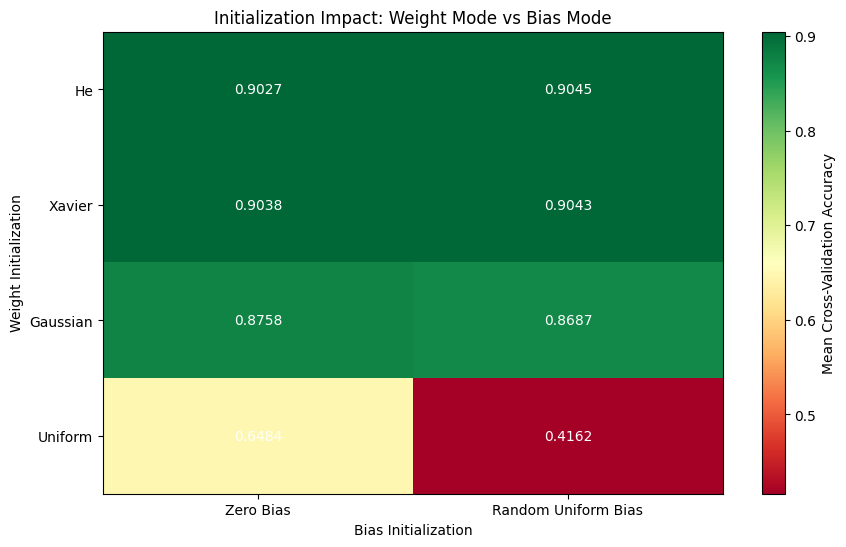

In [ ]:
result_accuracies = np.zeros((4, 2))

for weight_mode in [1, 2, 3, 4]: 
    for bias_mode in [0, 1]:

        run_means = []

        for i in range(10):
            net = Network([
                Linear(10, 32, init_mode_weight=weight_mode, init_mode_bias=bias_mode),
                Activation(),
                Linear(32, 7, init_mode_weight=weight_mode, init_mode_bias=bias_mode)
            ])

            # Due to this step being just to get intuition and rather lengthy, we use only 3 folds and 250 epochs for it to finish faster.
            fold_acc = k_fold_cross_validation(net, features, targets, Loss, k=3, epochs=250)
            fold_mean = np.mean(fold_acc)
            run_means.append(fold_mean)

        result_accuracies[weight_mode-1][bias_mode] = np.mean(run_means)

weight_labels = ["He", "Xavier", "Gaussian", "Uniform"]
bias_labels = ["Zero Bias", "Random Uniform Bias"]

# --- Heatmap Visualization ---
plt.figure(figsize=(10, 6))
plt.imshow(result_accuracies, cmap='RdYlGn', aspect='auto')
plt.colorbar(label='Mean Cross-Validation Accuracy')
plt.xticks(ticks=[0, 1], labels=bias_labels)
plt.yticks(ticks=[0, 1, 2, 3], labels=weight_labels)
plt.title("Initialization Impact: Weight Mode vs Bias Mode")
plt.xlabel("Bias Initialization")
plt.ylabel("Weight Initialization")

# Annotate with accuracy values
for i in [0, 1, 2, 3]:
    for j in [0, 1]:
        plt.text(j, i, f'{result_accuracies[i, j]:.4f}', 
                 ha='center', va='center', color='white')

plt.show()

# NOTE: This step takes roughly 3 minutes . You might switch from i in range (10) to just 1 or 2 repetitions per mode for faster results. 

We observe that He and Xavier initialization perform significantly better than Gaussian and Uniform and that results are very similar between those two. Random initialization for bias seems to not influence the accuracy much for Xe and Xavier. We will further investigate how these two perform with more epochs and better estimate (larger k for k-fold).

In [71]:
result_accuracies = [0, 0]

for weight_mode in [1, 2]: 

        run_means = []

        for i in range(1):
            net = Network([
                Linear(10, 32, init_mode_weight=weight_mode),
                Activation(),
                Linear(32, 7, init_mode_weight=weight_mode)
            ])

            
            fold_acc = k_fold_cross_validation(net, features, targets, Loss, k=10, epochs=1000)
            fold_mean = np.mean(fold_acc)
            run_means.append(fold_mean)

        result_accuracies[weight_mode-1]= np.mean(run_means)

print(f"He Initialization Accuracy: {result_accuracies[0]}")
print(f"Xavier Initialization Accuracy: {result_accuracies[1]}")


He Initialization Accuracy: 0.9294620832725565
Xavier Initialization Accuracy: 0.9261503055055835


We see that these two perform very similarly, with He being slightly better.

### 1.4 Optimization

#### Question 11

<div style="background-color:#f1be3e">

_Put your code blocks above (if any) and write your answer here._

</div>

#### Question 12

<div style="background-color:#f1be3e">

_Put your code blocks above (if any) and write your answer here._

</div>

### 1.5 Evaluation

#### Question 13

<div style="background-color:#f1be3e">

_Put your code blocks above (if any) and write your answer here._

</div>

#### Question 14

<div style="background-color:#f1be3e">

_Put your code blocks above (if any) and write your answer here._

</div>

#### Question 15

<div style="background-color:#f1be3e">

_Put your code blocks above (if any) and write your answer here._

</div>

### 1.6 Scikit-learn

#### Question 16

<div style="background-color:#f1be3e">

_Put your code blocks above (if any) and write your answer here._

</div>

#### Question 17

<div style="background-color:#f1be3e">

_Put your code blocks above (if any) and write your answer here._

</div>

### 1.7 Reflection

#### Question 18

<div style="background-color:#f1be3e">

_Write your answer here._

</div>

#### Question 19

<div style="background-color:#f1be3e">

_Write your answer here._

</div>

### 1.8 Pen and paper

#### Question 20

<div style="background-color:#f1be3e">

_Write your answer here. You can also choose to simply include a photo of your solution._

</div>

#### Question 21

<div style="background-color:#f1be3e">

_Write your answer here. You can also choose to simply include a photo of your solution._

</div>

### 1.9 Division of work

#### Question 22

<div style="background-color:#f1be3e">


|          Component          |  Name A   |  Name B   |  Name C   |  Name D   |
|-----------------------------|-----------|-----------|-----------|-----------|
| Code (design)               |     A     |     B     |     C     |     D     |
| Code (implementation)       |     A     |     B     |     C     |     D     |
| Code (validation)           |     A     |     B     |     C     |     D     |
| Experiments (execution)     |     A     |     B     |     C     |     D     |
| Experiments (analysis)      |     A     |     B     |     C     |     D     |
| Experiments (visualization) |     A     |     B     |     C     |     D     |
| Report (original draft)     |     A     |     B     |     C     |     D     |
| Report (reviewing, editing) |     A     |     B     |     C     |     D     |

</div>

### References

<div style="background-color:#f1be3e">

**If you made use of any non-course resources, cite them below.**

</div>